In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

print("Imports OK")

Imports OK


In [2]:
df = pd.read_csv("../data/synthetic/consultation_notes.csv")

print(f" {len(df)} notes chargées")
print(f"\nDistribution des catégories :")
print(df["category"].value_counts())
print(f"\nExemple de note (cardio) :")
print(df[df["category"] == "cardio"]["note"].iloc[0])

 500 notes chargées

Distribution des catégories :
category
normal        217
metabolic     119
infectious     99
cardio         65
Name: count, dtype: int64

Exemple de note (cardio) :
Oedème des membres inférieurs bilatéral. Essoufflement au moindre effort. Bilan cardiaque requis.


In [3]:
# Encodage des catégories en labels numériques
category_to_label = {
    "normal":     0,
    "cardio":     1,
    "metabolic":  2,
    "infectious": 3
}
label_to_category = {v: k for k, v in category_to_label.items()}

df["label_encoded"] = df["category"].map(category_to_label)

# Split train / test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    df["note"],
    df["label_encoded"],
    test_size=0.2,
    random_state=42,
    stratify=df["label_encoded"]  # Garantit la même distribution dans train et test
)

print(f" Train : {len(X_train)} notes | Test : {len(X_test)} notes")
print(f"\nDistribution train :")
print(pd.Series(y_train).map(label_to_category).value_counts())

 Train : 400 notes | Test : 100 notes

Distribution train :
label_encoded
normal        174
metabolic      95
infectious     79
cardio         52
Name: count, dtype: int64


In [4]:
# Pipeline sklearn :
# 1. TF-IDF : transforme le texte en vecteur numérique
#    (chaque mot devient une dimension, pondérée par sa fréquence et rareté)
# 2. LogisticRegression : classifie le vecteur en catégorie clinique

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),     # unigrammes + bigrammes (ex: "douleur thoracique")
        max_features=5000,       # limite la dimensionnalité
        sublinear_tf=True,       # lissage logarithmique des fréquences
        strip_accents="unicode"  # normalise les accents
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        C=1.0,
        multi_class="multinomial",
        solver="lbfgs",
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)
print("Modèle entraîné")

# Évaluation
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)

print("\n Rapport de classification :")
print(classification_report(
    y_test, y_pred,
    target_names=list(category_to_label.keys())
))

auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"AUC macro (OvR) : {auc:.4f}")

Modèle entraîné

 Rapport de classification :
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        43
      cardio       1.00      1.00      1.00        13
   metabolic       1.00      1.00      1.00        24
  infectious       1.00      1.00      1.00        20

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

AUC macro (OvR) : 1.0000


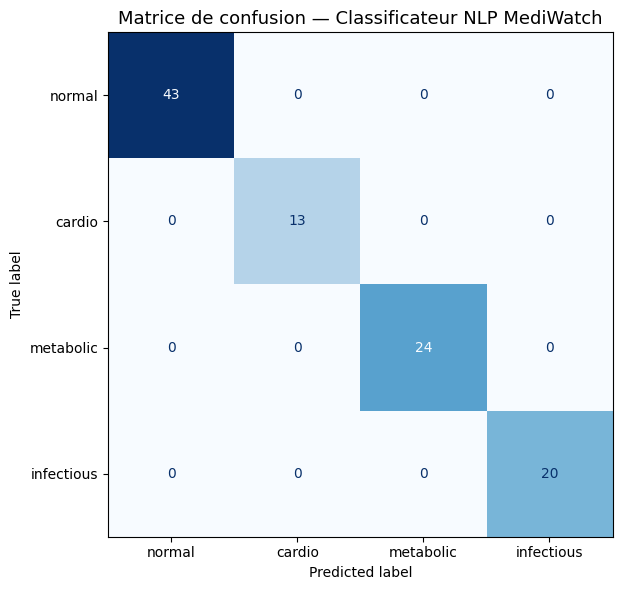

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(category_to_label.keys())
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matrice de confusion — Classificateur NLP MediWatch", fontsize=13)
plt.tight_layout()
plt.savefig("../data/processed/confusion_matrix_nlp.png", dpi=150)
plt.show()

In [6]:
test_phrases = [
    "Patient avec douleur thoracique sévère et essoufflement brutal",
    "Glycémie à 13 mmol/L, patient diabétique sous metformine",
    "Fièvre à 39.5°C depuis 3 jours, toux productive",
    "Consultation de routine, aucune plainte, renouvellement ordonnance",
    "Palpitations nocturnes, oedème des chevilles, antécédents cardiaques"
]

print(" Test du classificateur sur phrases libres :\n")
for phrase in test_phrases:
    pred_label = pipeline.predict([phrase])[0]
    pred_proba = pipeline.predict_proba([phrase])[0]
    pred_category = label_to_category[pred_label]
    confidence = round(pred_proba[pred_label] * 100, 1)
    print(f" \"{phrase[:60]}...\"")
    print(f"   → Catégorie prédite : {pred_category.upper()} ({confidence}% confiance)\n")

 Test du classificateur sur phrases libres :

 "Patient avec douleur thoracique sévère et essoufflement brut..."
   → Catégorie prédite : CARDIO (31.1% confiance)

 "Glycémie à 13 mmol/L, patient diabétique sous metformine..."
   → Catégorie prédite : METABOLIC (44.6% confiance)

 "Fièvre à 39.5°C depuis 3 jours, toux productive..."
   → Catégorie prédite : INFECTIOUS (78.5% confiance)

 "Consultation de routine, aucune plainte, renouvellement ordo..."
   → Catégorie prédite : NORMAL (89.2% confiance)

 "Palpitations nocturnes, oedème des chevilles, antécédents ca..."
   → Catégorie prédite : CARDIO (60.6% confiance)



In [7]:
os.makedirs("../ml_models/text", exist_ok=True)

model_path = "../ml_models/text/tfidf_logreg_classifier.pkl"
with open(model_path, "wb") as f:
    pickle.dump(pipeline, f)

# Sauvegarde du mapping labels
import json
with open("../ml_models/text/label_mapping.json", "w") as f:
    json.dump({"label_to_category": label_to_category,
               "category_to_label": category_to_label}, f)

print(f" Modèle sauvegardé : {model_path}")

# Vérification du rechargement
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict(["douleur thoracique sévère"])
print(f" Modèle rechargé OK — prédiction test : {label_to_category[test_pred[0]]}")

 Modèle sauvegardé : ../ml_models/text/tfidf_logreg_classifier.pkl
 Modèle rechargé OK — prédiction test : normal
